In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("RetailOrderAnalyisis").getOrCreate()

In [3]:
from google.colab import files
upload = files.upload()

Saving Online Retail.csv to Online Retail.csv


In [4]:
df = spark.read.csv("Online Retail.csv", header=True, inferSchema=True)



In [5]:
df.show()
df.printSchema()

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|12/1/2010 8:26|     4.

In [6]:
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [7]:
df.count()

541909

In [8]:
df.filter(df.CustomerID.isNull()).count()

135080

In [9]:
df.filter(df.Description.isNull()).count()

1454

In [10]:
df.filter(df.CustomerID.isNull() & df.Description.isNull()).count()

1454

In [11]:
df.filter(df.Quantity.isNull()).count()

0

In [12]:
df.filter(df.UnitPrice.isNull()).count()

0

In [13]:
df.filter(df.Country.isNull()).count()

0

In [14]:
df.filter(df.InvoiceDate.isNull()).count()

0

In [15]:
clean_df = df.na.drop(subset = ["CustomerID","Description"])

In [16]:
clean_df.filter(clean_df.CustomerID.isNull()).count()

0

dubligate print

In [17]:
clean_df.groupBy(df.columns) \
  .count() \
  .filter("count > 1") \
  .show()

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+-----+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|count|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+-----+
|   537051|    85175|CACTI T-LIGHT CAN...|      32| 12/5/2010 11:12|     0.42|     15708|United Kingdom|    2|
|   541985|    22588|CARD HOLDER GINGH...|       2| 1/24/2011 15:52|     2.55|     15052|United Kingdom|    2|
|   542192|    84378|SET OF 3 HEART CO...|       3| 1/26/2011 11:27|     1.25|     14049|United Kingdom|    2|
|   545721|    22697|GREEN REGENCY TEA...|       1|  3/7/2011 10:52|     2.95|     15039|United Kingdom|    2|
|   546429|    22417|PACK OF 60 SPACEB...|       1| 3/13/2011 15:25|     0.55|     17611|United Kingdom|    2|
|   546502|    84692|BOX OF 24 COCKTAI...|       1| 3/14/2011 11:46|     0.42|     16005|United Kingdom|    2|
|

In [18]:
clean_df.distinct().count()

401604

In [19]:
clean_df.count()

406829

remofe **dubligate**

In [20]:
df_no_dupes = clean_df.dropDuplicates()

check negative or 0 qty


In [21]:
df_no_dupes.filter(df_no_dupes.Quantity <= 0).count()

8872

remove **negative**

In [22]:
df_postive = df_no_dupes.filter(df_no_dupes.Quantity >0)

In [23]:
from pyspark.sql.functions import to_timestamp

df_postive = df_postive.withColumn("InvoiceDate", to_timestamp("InvoiceDate","MM/dd/yyyy HH:mm"))

In [24]:
df_postive.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



--- 🔹 Step 3. Data **Transformation**

In [25]:
from pyspark.sql.functions import col
df_trans = df_postive.withColumn("Revenue",col("Quantity")* col("UnitPrice"))

In [26]:
df_trans.select("Quantity", "UnitPrice", "Revenue").show()

+--------+---------+------------------+
|Quantity|UnitPrice|           Revenue|
+--------+---------+------------------+
|       6|      2.1|12.600000000000001|
|       6|     4.25|              25.5|
|      12|     0.42|              5.04|
|       1|     4.25|              4.25|
|       2|     3.75|               7.5|
|      12|     1.45|              17.4|
|       1|     4.25|              4.25|
|       1|     1.95|              1.95|
|      12|      2.1|25.200000000000003|
|       2|     7.95|              15.9|
|       6|     2.95|17.700000000000003|
|       1|      8.5|               8.5|
|       2|     6.75|              13.5|
|       4|     0.29|              1.16|
|      12|     1.65|19.799999999999997|
|       4|    10.95|              43.8|
|       2|     7.65|              15.3|
|       8|      2.1|              16.8|
|      24|     0.85|              20.4|
|      48|     0.85|              40.8|
+--------+---------+------------------+
only showing top 20 rows



In [27]:
from pyspark.sql.functions import round
df_trans = df_trans.withColumn("Revenue", round(col("Revenue"),2))




In [28]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

In [29]:
df_trans.show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Revenue|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+
|   536367|    22745|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2.1|     13047|United Kingdom|   12.6|
|   536368|    22960|JAM MAKING SET WI...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   25.5|
|   536388|    22915|ASSORTED BOTTLE T...|      12|2010-12-01 09:59:00|     0.42|     16250|United Kingdom|   5.04|
|   536401|    21464|DISCO BALL ROTATO...|       1|2010-12-01 11:21:00|     4.25|     15862|United Kingdom|   4.25|
|   536412|    22569|FELTCRAFT CUSHION...|       2|2010-12-01 11:49:00|     3.75|     17920|United Kingdom|    7.5|
|   536425|    22645|CERAMIC HEART FAI...|      12|2010-12-01 12:08:00| 

In [30]:
from pyspark.sql.functions import year , month, day

df_trans = df_trans.withColumn("Year", year("InvoiceDate"))
df_trans = df_trans.withColumn("Month", month("InvoiceDate"))
df_trans = df_trans.withColumn("Day", day("InvoiceDate"))

In [31]:
print(df_trans.columns)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day']


In [32]:
df_trans.select("year").show()

+----+
|year|
+----+
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
|2010|
+----+
only showing top 20 rows



In [33]:
df_trans.show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Revenue|Year|Month|Day|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|   536367|    22745|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2.1|     13047|United Kingdom|   12.6|2010|   12|  1|
|   536368|    22960|JAM MAKING SET WI...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   25.5|2010|   12|  1|
|   536388|    22915|ASSORTED BOTTLE T...|      12|2010-12-01 09:59:00|     0.42|     16250|United Kingdom|   5.04|2010|   12|  1|
|   536401|    21464|DISCO BALL ROTATO...|       1|2010-12-01 11:21:00|     4.25|     15862|United Kingdom|   4.25|2010|   12|  1|
|   536412|    22569|FELTCRAFT CUSHION...|       2|2010-12-01 11:49:00|     3.75|  

In [34]:
from pyspark.sql.functions import trim , upper

df_trans = df_trans.withColumn("Country", upper(trim(col("Country"))))

In [35]:
df_trans.show(4)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Revenue|Year|Month|Day|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|   536367|    22745|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2.1|     13047|UNITED KINGDOM|   12.6|2010|   12|  1|
|   536368|    22960|JAM MAKING SET WI...|       6|2010-12-01 08:34:00|     4.25|     13047|UNITED KINGDOM|   25.5|2010|   12|  1|
|   536388|    22915|ASSORTED BOTTLE T...|      12|2010-12-01 09:59:00|     0.42|     16250|UNITED KINGDOM|   5.04|2010|   12|  1|
|   536401|    21464|DISCO BALL ROTATO...|       1|2010-12-01 11:21:00|     4.25|     15862|UNITED KINGDOM|   4.25|2010|   12|  1|
+---------+---------+--------------------+--------+-------------------+---------+--

Exploratory Data Analysis (EDA)

In [36]:
from pyspark.sql.functions import sum

df_trans.agg(sum("Revenue")).show()

+-----------------+
|     sum(Revenue)|
+-----------------+
|8887208.890000854|
+-----------------+



In [37]:
from pyspark.sql.functions import sum

df_trans.agg(sum("Revenue").alias("Totoal_Revenue")).show()
df_trans.agg(sum("Quantity").alias("Total_Quantity")).show()


+-----------------+
|   Totoal_Revenue|
+-----------------+
|8887208.890000854|
+-----------------+

+--------------+
|Total_Quantity|
+--------------+
|       5165886|
+--------------+



Revenue by country

In [38]:
from pyspark.sql.functions import sum

df_trans.groupBy("Country").agg(sum("Revenue")).show()



+--------------------+------------------+
|             Country|      sum(Revenue)|
+--------------------+------------------+
|               JAPAN|37416.369999999995|
|         UNSPECIFIED|2660.7700000000013|
|               MALTA|           2725.59|
|                 RSA|1002.3100000000001|
|           LITHUANIA|           1661.06|
|      UNITED KINGDOM| 7285024.640000299|
|  EUROPEAN COMMUNITY|           1300.25|
|      CZECH REPUBLIC|            826.74|
|              CANADA|           3666.38|
|              POLAND|           7334.65|
|UNITED ARAB EMIRATES|1902.2799999999993|
|              FRANCE|208934.31000000038|
|                EIRE| 265262.4599999994|
|           SINGAPORE|21279.290000000008|
|             AUSTRIA|          10198.68|
|        SAUDI ARABIA|            145.92|
|         SWITZERLAND| 56443.95000000013|
|                 USA| 3580.390000000001|
|              NORWAY|          36165.44|
|             FINLAND| 22546.07999999999|
+--------------------+------------

customer analysis

no of unique customers

In [39]:
df_trans.select("CustomerID").distinct().count()

4339

top customer by revenuew

In [40]:
df_trans.groupBy("CustomerID").agg(sum("Revenue")).orderBy("sum(Revenue)", ascending=False).show()

+----------+------------------+
|CustomerID|      sum(Revenue)|
+----------+------------------+
|     14646|280206.01999999967|
|     18102|          259657.3|
|     17450|194390.79000000004|
|     16446|          168472.5|
|     14911| 143711.1699999999|
|     12415|124914.53000000003|
|     14156|117210.08000000006|
|     17511|          91062.38|
|     16029| 80850.83999999998|
|     12346|           77183.6|
|     16684|          66653.56|
|     14096| 65164.79000000008|
|     13694| 65039.62000000001|
|     15311| 60632.75000000007|
|     13089| 58762.08000000005|
|     17949| 58510.48000000001|
|     15769|          56252.72|
|     15061| 54534.13999999997|
|     14298| 51527.29999999996|
|     14088|50491.809999999954|
+----------+------------------+
only showing top 20 rows



** Product analysis**

Top 10 selling products

In [41]:
df_trans.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Revenue|Year|Month|Day|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------+----+-----+---+
|   536367|    22745|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2.1|     13047|UNITED KINGDOM|   12.6|2010|   12|  1|
|   536368|    22960|JAM MAKING SET WI...|       6|2010-12-01 08:34:00|     4.25|     13047|UNITED KINGDOM|   25.5|2010|   12|  1|
|   536388|    22915|ASSORTED BOTTLE T...|      12|2010-12-01 09:59:00|     0.42|     16250|UNITED KINGDOM|   5.04|2010|   12|  1|
|   536401|    21464|DISCO BALL ROTATO...|       1|2010-12-01 11:21:00|     4.25|     15862|UNITED KINGDOM|   4.25|2010|   12|  1|
|   536412|    22569|FELTCRAFT CUSHION...|       2|2010-12-01 11:49:00|     3.75|  

In [42]:
df_trans.groupBy("StockCode","Description").agg(sum("Quantity")).orderBy("sum(Quantity)", ascending=False).show(10)

+---------+--------------------+-------------+
|StockCode|         Description|sum(Quantity)|
+---------+--------------------+-------------+
|    23843|PAPER CRAFT , LIT...|        80995|
|    23166|MEDIUM CERAMIC TO...|        77916|
|    84077|WORLD WAR 2 GLIDE...|        54319|
|   85099B|JUMBO BAG RED RET...|        46078|
|   85123A|WHITE HANGING HEA...|        36706|
|    84879|ASSORTED COLOUR B...|        35263|
|    21212|PACK OF 72 RETROS...|        33670|
|    22197|      POPCORN HOLDER|        30919|
|    23084|  RABBIT NIGHT LIGHT|        27153|
|    22492|MINI PAINT SET VI...|        26076|
+---------+--------------------+-------------+
only showing top 10 rows



top 10 revenue products

In [43]:
df_trans.groupBy("StockCode","Description").agg(sum("Revenue")).orderBy("sum(Revenue)",ascending = False).show(10)

+---------+--------------------+------------------+
|StockCode|         Description|      sum(Revenue)|
+---------+--------------------+------------------+
|    23843|PAPER CRAFT , LIT...|          168469.6|
|    22423|REGENCY CAKESTAND...|142264.74999999977|
|   85123A|WHITE HANGING HEA...|100392.09999999966|
|   85099B|JUMBO BAG RED RET...| 85040.54000000047|
|    23166|MEDIUM CERAMIC TO...|          81416.73|
|     POST|             POSTAGE| 77803.95999999999|
|    47566|       PARTY BUNTING| 68785.22999999991|
|    84879|ASSORTED COLOUR B...| 56413.03000000046|
|        M|              Manual| 53419.93000000001|
|    23084|  RABBIT NIGHT LIGHT| 51251.23999999985|
+---------+--------------------+------------------+
only showing top 10 rows



Time Analysis

monthly trend analysis

In [44]:
from pyspark.sql.functions import year, month, sum as _sum

monthly_rev = (
    df_trans
    .groupBy(year("InvoiceDate").alias("Year"), month("InvoiceDate").alias("Month"))
    .agg(_sum("Revenue").alias("TotalRevenue"))
    .orderBy("Year", "Month")
)

monthly_rev.show()


+----+-----+------------------+
|Year|Month|      TotalRevenue|
+----+-----+------------------+
|2010|   12| 570422.7300000123|
|2011|    1| 568101.3100000045|
|2011|    2|446084.92000000353|
|2011|    3| 594081.7600000085|
|2011|    4| 468374.3300000027|
|2011|    5| 677355.1500000055|
|2011|    6| 660046.0500000052|
|2011|    7| 598962.9000000027|
|2011|    8| 644051.0400000022|
|2011|    9| 950690.2000000183|
|2011|   10|1035642.4500000346|
|2011|   11|1156205.6100000343|
|2011|   12| 517190.4400000053|
+----+-----+------------------+



Yearly trend analysis

In [62]:
from pyspark.sql.functions import year, sum as _sum
Yearly_rev = df_trans.groupBy(year("InvoiceDate").alias("Year")).agg(_sum("Revenue").alias("TotalRevenue")).orderBy("Year")

Yearly_rev.show()

+----+-----------------+
|Year|     TotalRevenue|
+----+-----------------+
|2010|570422.7300000123|
|2011| 8316786.16000041|
+----+-----------------+



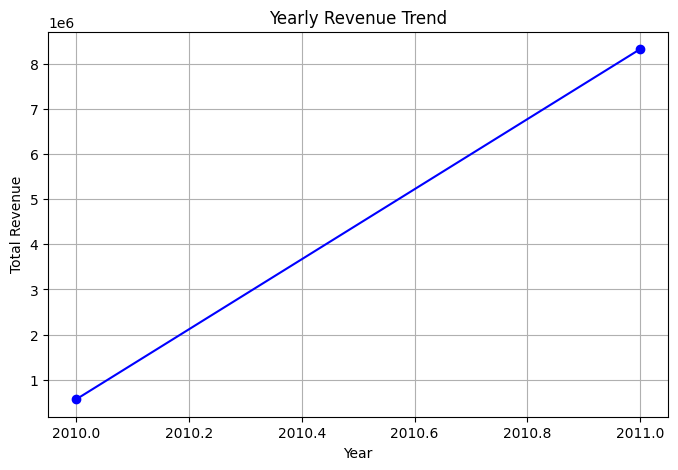

In [63]:
import matplotlib.pyplot as plt

# Convert PySpark DF -> Pandas DF
pdf = Yearly_rev.toPandas()

# Plot
plt.figure(figsize=(8,5))
plt.plot(pdf["Year"], pdf["TotalRevenue"], marker="o", color="b")
plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()


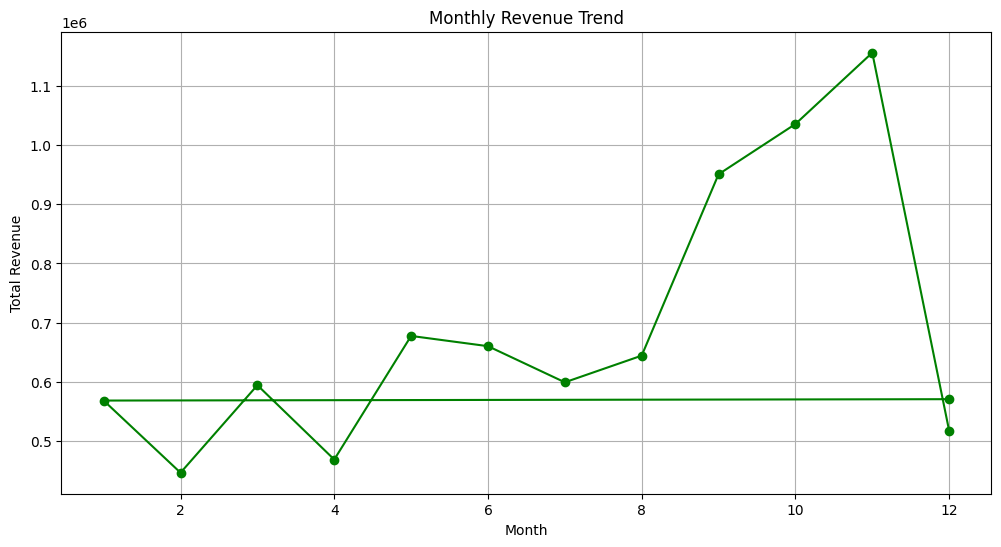

In [65]:
pdf_month = Monthly_rev.toPandas()

plt.figure(figsize=(12,6))
plt.plot(pdf_month["Month"], pdf_month["TotalRevenue"], marker="o", color="g")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()


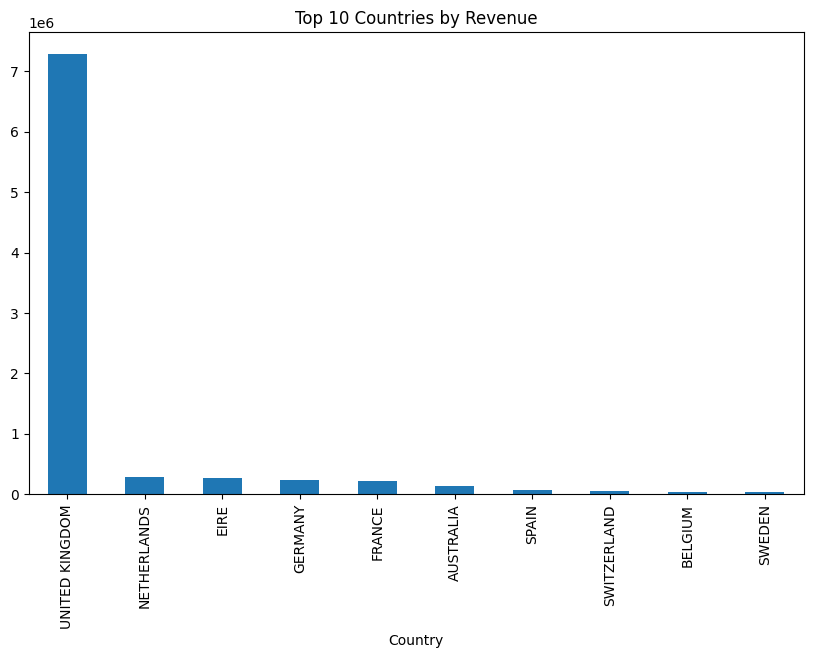

In [66]:
pdf_country = df_trans.groupBy("Country").agg(_sum("Revenue").alias("Revenue")).toPandas()

pdf_country.sort_values("Revenue", ascending=False).head(10).plot(
    kind="bar", x="Country", y="Revenue", figsize=(10,6), legend=False
)
plt.title("Top 10 Countries by Revenue")
plt.show()
